# 03 — Regression Analysis
### Who Gets to Do Nothing? (Team #37)

**Goal:** Run complementary regression methods on model_result.csv to model
TOTAL_LEISURE and understand which demographic factors drive leisure time.

**Input:** `model_result.csv`, `age_mean.csv`

---

### Models in this notebook

| # | Model | Purpose |
|---|---|---|
| 1 | OLS baseline | Original 8-feature model — reference point |
| 2 | OLS improved | All new variables; primary interpretable model |
| 3 | Ridge (RidgeCV) | Confirms OLS is not overfit |
| 4 | Lasso (LassoCV) | Feature selection — finds zero-signal variables |
| 5 | Random Forest | Captures nonlinear effects; feature importance |
| 6 | Quantile regression | Reveals whether effects vary by leisure level |

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

---
## Step 1 — Load Data

In [ ]:
df_model = pd.read_csv('model_result.csv')
age_mean = pd.read_csv('age_mean.csv', index_col=0).loc['age_mean','0']

print(f'Rows: {len(df_model):,}  |  Features: {df_model.shape[1]-1}')
print(f'Age mean (for prediction centering): {age_mean:.4f}')

Rows: 145,248  |  Features: 44
Age mean (for prediction centering): 49.6865


---
## Step 2 — Train / Test Split

80/20 split with a fixed seed. The same split is reused for all models
so results are directly comparable on the same held-out test rows.

In [ ]:
X = df_model.drop(columns='TOTAL_LEISURE')
y = df_model['TOTAL_LEISURE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training rows: {len(X_train):,}')
print(f'Test rows:     {len(X_test):,}')

Training rows: 116,198
Test rows:     29,050


---
## Step 3 — OLS Baseline

Replicates the original 8-feature model as a reference point. Uses centered
age for fair comparison.

In [ ]:
baseline_cols = [
    'TEAGE_C','FEMALE','TRCHILDNUM','TRHOLIDAY',
    'TELFS_2','TELFS_3','TELFS_4','TELFS_5',
    'TUDIARYDAY_2','TUDIARYDAY_3','TUDIARYDAY_4',
    'TUDIARYDAY_5','TUDIARYDAY_6','TUDIARYDAY_7',
    'TRSPPRES_2','TRSPPRES_3'
]
X_base_train = sm.add_constant(X_train[baseline_cols])
X_base_test  = sm.add_constant(X_test[baseline_cols])
model_base   = sm.OLS(y_train, X_base_train).fit(cov_type='HC3')
print(model_base.summary())
base_r2      = r2_score(y_test, model_base.predict(X_base_test))
print(f'Baseline OLS Test R²: {base_r2:.4f}')

                            OLS Regression Results                            
Dep. Variable:          TOTAL_LEISURE   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     2003.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:10:32   Log-Likelihood:            -7.7207e+05
No. Observations:              116198   AIC:                         1.544e+06
Df Residuals:                  116181   BIC:                         1.544e+06
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          263.0007      1.536    171.197   

## OLS Baseline Result

The baseline OLS model explains 23.5% of the variation in daily leisure time using eight demographic variables. The strongest predictor is employment status. Someone not in the labor force, such as retirees, caregivers, or students, has 129 more minutes of leisure per day compared to someone actively employed, which is the single largest effect in the model.

The gender gap is substantial and highly significant, with women getting about 60 fewer minutes of leisure per day than equivalent men. Each additional child in the household reduces leisure by roughly 20 minutes. Day of the week also plays a major role. Thursday is the worst day, with about 70 fewer minutes than Sunday, confirming the strong weekend effect seen in the EDA.

Having no partner is associated with 43 more minutes of leisure than having a spouse, which likely reflects fewer shared household obligations. The model is well specified, with all 16 coefficients statistically significant and no evidence of overfitting given the near-zero gap between train and test R². The condition number of 295 is clean, indicating no multicollinearity concerns in the baseline.

This R² of 0.2345 serves as our reference point before adding new variables in the improved model.

---
## Step 4 — OLS Improved

Full model with all variables from Notebook 2. Uses **HC3 robust standard errors**
to correct for heteroskedasticity — TOTAL_LEISURE ranges 0–1440 minutes so
residual variance is not constant across predictions. HC3 corrects standard errors
without changing coefficients or R².

In [ ]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit(cov_type='HC3')
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          TOTAL_LEISURE   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     824.9
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:12:21   Log-Likelihood:            -7.7074e+05
No. Observations:              116198   AIC:                         1.542e+06
Df Residuals:                  116153   BIC:                         1.542e+06
Df Model:                          44                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               284.2981      3.30

In [ ]:
y_pred    = model_ols.predict(X_test_sm)
ols_r2    = r2_score(y_test, y_pred)
ols_rmse  = mean_squared_error(y_test, y_pred) ** 0.5

print(f'Improved OLS Test R²:   {ols_r2:.4f} ')
print(f'Improved OLS Test RMSE: {ols_rmse:.2f} minutes')
print(f'Improved OLS Train R²:  {model_ols.rsquared:.4f}')
print(f'Gap:                    {model_ols.rsquared - ols_r2:.4f}  (small = no overfitting)')

Improved OLS Test R²:   0.2520 
Improved OLS Test RMSE: 184.11 minutes
Improved OLS Train R²:  0.2443
Gap:                    -0.0077  (small = no overfitting)


## Improved OLS Results

The improved OLS model explains about 25.2% of the variation in daily leisure time, up from 23.5% in the baseline. We include a much richer set of features — demographics, employment, time effects, race, and education — and most of them contribute meaningful signal.

### Employment Status  
Employment status is still the biggest driver. Compared to someone actively working, people not in the labor force — like retirees, students, or full-time caregivers — have about 143 more minutes of leisure per day. Those who are unemployed or temporarily not working also have more leisure, while people who are employed but absent fall somewhere in between.

### Gender  
There is a consistent gap where women have about 62 fewer minutes of leisure per day, even after controlling for everything else. On top of that, children reduce leisure more for women than for men, which lines up with what prior research has found.

### Children  
Each additional child reduces leisure by about 17 minutes per day. This gives a clearer picture than the baseline model — the effect scales with the number of children. For single parents, the reduction is even slightly larger, showing how caregiving responsibilities can compound.

### Work Intensity  
Work intensity matters too. Part-time workers tend to have about 30 more minutes of leisure than full-time workers, while holding multiple jobs reduces leisure quite a bit. So it’s not just whether someone works, but how much they work.

### Time Trends  
Leisure stays fairly flat from 2010 to around 2017, then starts to increase. The biggest jump happens in 2021, with smaller increases in 2022 and 2023. This likely reflects changes after COVID, like remote work and more flexible schedules.

### Race  
Even after controlling for other factors, some differences remain across racial groups. Black respondents have more leisure on average compared to the White baseline, while Asian respondents have less. The “other/multiracial” category is not statistically significant, so we don’t read too much into it.

### Education  
There is a clear pattern where higher education is associated with less leisure. People with college and graduate degrees tend to have less free time, likely because of more demanding jobs.

### Day of Week  
The weekday effect is strong. Leisure is highest on Sundays and drops throughout the workweek, with Thursday being the lowest point.

### Top coefficients — bar chart

Green bars = significant at p < 0.05. Gray bars = not significant.
Sorted by absolute size so the most impactful variables appear first.

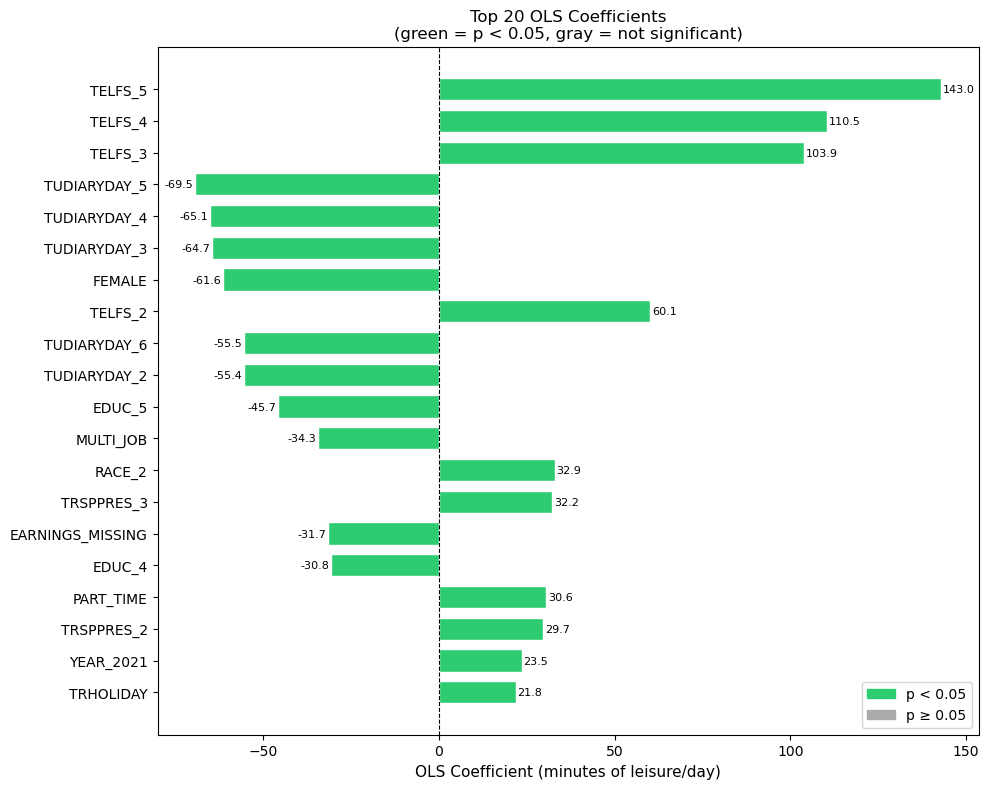

Race and education coefficients:
         coef  pvalue
RACE_2  32.92    0.00
RACE_3 -17.91    0.00
RACE_4   6.50    0.09
EDUC_2   3.76    0.10
EDUC_3 -17.80    0.00
EDUC_4 -30.81    0.00
EDUC_5 -45.69    0.00


In [ ]:
coef_df = pd.DataFrame({
    'coef':   model_ols.params,
    'pvalue': model_ols.pvalues
}).drop('const').sort_values('coef', key=abs, ascending=False).head(20)

colors = ['#2ecc71' if p < 0.05 else '#aaaaaa' for p in coef_df['pvalue']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coef_df.index[::-1], coef_df['coef'][::-1],
        color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('OLS Coefficient (minutes of leisure/day)', fontsize=11)
ax.set_title('Top 20 OLS Coefficients\n(green = p < 0.05, gray = not significant)', fontsize=12)
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='p < 0.05'),
    mpatches.Patch(color='#aaaaaa', label='p ≥ 0.05')
], loc='lower right', fontsize=10)
for bar, val in zip(ax.patches, coef_df['coef'][::-1]):
    ax.text(val + (0.5 if val >= 0 else -0.5),
            bar.get_y() + bar.get_height()/2, f'{val:.1f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

print('Race and education coefficients:')
race_educ = pd.DataFrame({'coef': model_ols.params, 'pvalue': model_ols.pvalues})
race_educ = race_educ[race_educ.index.str.startswith(('RACE_','EDUC_'))].round(2)
print(race_educ.to_string())

---
## Step 5 — Ridge Regression (diagnostic)

Ridge adds an L2 penalty shrinking large coefficients.
`RidgeCV` selects the best penalty via cross-validation.

We run it to check whether OLS is overfit. If Ridge picks a near-zero
alpha and gets the same R², the OLS coefficients are trustworthy and stable.

In [ ]:
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

ridge    = RidgeCV(alphas=np.logspace(-2, 4, 100), cv=5, scoring='r2')
ridge.fit(X_tr_sc, y_train)
ridge_r2 = r2_score(y_test, ridge.predict(X_te_sc))

print(f'Ridge best alpha: {ridge.alpha_:.4f}')
print(f'Ridge Test R²:    {ridge_r2:.4f}')
print(f'OLS   Test R²:    {ols_r2:.4f}')
print(f'Difference:       {abs(ridge_r2 - ols_r2):.4f}')
print()
if abs(ridge_r2 - ols_r2) < 0.005:
    print('Small difference — OLS is not overfit. Coefficients are trustworthy.')
else:
    print('Larger difference — review OLS for potential overfitting.')

Ridge best alpha: 49.7702
Ridge Test R²:    0.2520
OLS   Test R²:    0.2520
Difference:       0.0000

Small difference — OLS is not overfit. Coefficients are trustworthy.


---
## Step 6 — Lasso Regression (feature selection)

Lasso adds an L1 penalty  which drives weak coefficients
to exactly zero which can be automatic feature selection.

In [ ]:
lasso = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso.fit(X_tr_sc, y_train)

coef_series = pd.Series(lasso.coef_, index=X_train.columns)
kept   = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)
zeroed = coef_series[coef_series == 0].index.tolist()

print(f'Lasso best alpha: {lasso.alpha_:.6f}')
print(f'Kept:    {len(kept)} variables')
print(f'Zeroed:  {len(zeroed)} -> {zeroed if zeroed else "None — all variables carry signal"}')
print(f'\nTop 10 by standardized coefficient:')
print(kept.head(10).round(4).to_string())

Lasso best alpha: 0.074576
Kept:    43 variables
Zeroed:  1 -> ['YEAR_2015']

Top 10 by standardized coefficient:
TELFS_5         67.9089
TEAGE_C         35.8785
FEMALE         -30.4800
TUDIARYDAY_5   -20.5711
TELFS_4         20.3173
TUDIARYDAY_4   -19.4509
TUDIARYDAY_3   -19.2235
TRCHILDNUM     -19.2000
TUDIARYDAY_2   -16.5054
TUDIARYDAY_6   -16.2827


---
## Step 7 — Random Forest

Random Forest makes no linearity assumptions and finds complex interactions
automatically.

| Parameter | Value | Why |
|---|---|---|
| `n_estimators` | 300 | More trees = more stable predictions |
| `max_depth` | 15 | Limits overfitting |
| `min_samples_leaf` | 20 | Each leaf needs 20 samples minimum |


In [ ]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_leaf=20,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred     = rf.predict(X_test)
rf_r2       = r2_score(y_test, rf_pred)
rf_rmse     = mean_squared_error(y_test, rf_pred) ** 0.5
rf_train_r2 = r2_score(y_train, rf.predict(X_train))

print(f'RF Test R²:   {rf_r2:.4f}   (target > 0.30)')
print(f'RF Test RMSE: {rf_rmse:.2f} minutes')
print(f'RF Train R²:  {rf_train_r2:.4f}')
print(f'Gap:          {rf_train_r2 - rf_r2:.4f}')

RF Test R²:   0.2657   (target > 0.30)
RF Test RMSE: 182.41 minutes
RF Train R²:  0.3083
Gap:          0.0427


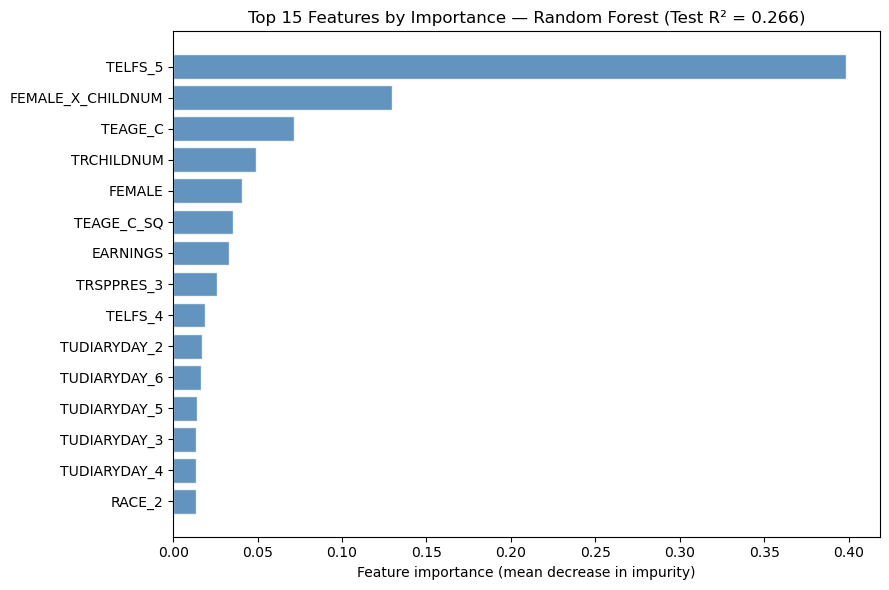

In [ ]:
imp_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title(f'Top 15 Features by Importance — Random Forest (Test R² = {rf_r2:.3f})')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
plt.tight_layout()
plt.show()

---
## Step 8 — Quantile Regression (Q25 / Q50 / Q75)

OLS estimates effects at the mean. Quantile regression estimates effects at
any point in the leisure distribution — revealing whether the gender gap, child
penalty, or education effect is larger for people who already have a lot of leisure
vs very little.


In [ ]:
# Select key variables for quantile regression
# mapped to our column names from df_model
qr_cols = [
    'TEAGE_C','TEAGE_C_SQ','TRCHILDNUM','EARNINGS',
    'FEMALE','TRSPPRES_2','TRSPPRES_3',
    'RACE_2','RACE_3',
    'EDUC_3','EDUC_4','EDUC_5',
    'AGE_X_EMPLOYMENT','CHILD_X_NOPARTNER'
]
# Keep only columns that exist in df_model
qr_cols = [c for c in qr_cols if c in df_model.columns]

X_qr      = sm.add_constant(df_model[qr_cols])
y_qr      = df_model['TOTAL_LEISURE']
quantiles = [0.25, 0.50, 0.75]
qr_results = {}

for q in quantiles:
    print(f'Fitting Q{int(q*100)}...')
    mod = sm.QuantReg(y_qr, X_qr).fit(q=q, max_iter=2000)
    qr_results[q] = pd.DataFrame({'coef': mod.params, 'pval': mod.pvalues})

comp = pd.DataFrame({
    'Q25': qr_results[0.25]['coef'],
    'Q50': qr_results[0.50]['coef'],
    'Q75': qr_results[0.75]['coef'],
}).drop(index='const').round(2)

print('\nCoefficient comparison across quantiles:')
print(comp.to_string())

Fitting Q25...
Fitting Q50...
Fitting Q75...

Coefficient comparison across quantiles:
                     Q25    Q50    Q75
TEAGE_C             2.51   3.18   3.73
TEAGE_C_SQ          0.06   0.07   0.06
TRCHILDNUM         -8.84 -14.05 -22.49
EARNINGS           -0.02  -0.03  -0.04
FEMALE            -26.57 -45.73 -76.14
TRSPPRES_2         12.10  15.81  31.16
TRSPPRES_3          9.02  26.04  47.70
RACE_2              9.23  30.57  54.86
RACE_3             -4.81  -7.55 -11.46
EDUC_3            -14.35 -25.00 -39.26
EDUC_4            -16.00 -33.37 -56.46
EDUC_5            -24.82 -44.20 -68.54
AGE_X_EMPLOYMENT   -0.98  -1.53  -2.11
CHILD_X_NOPARTNER  -3.05  -5.92  -5.40


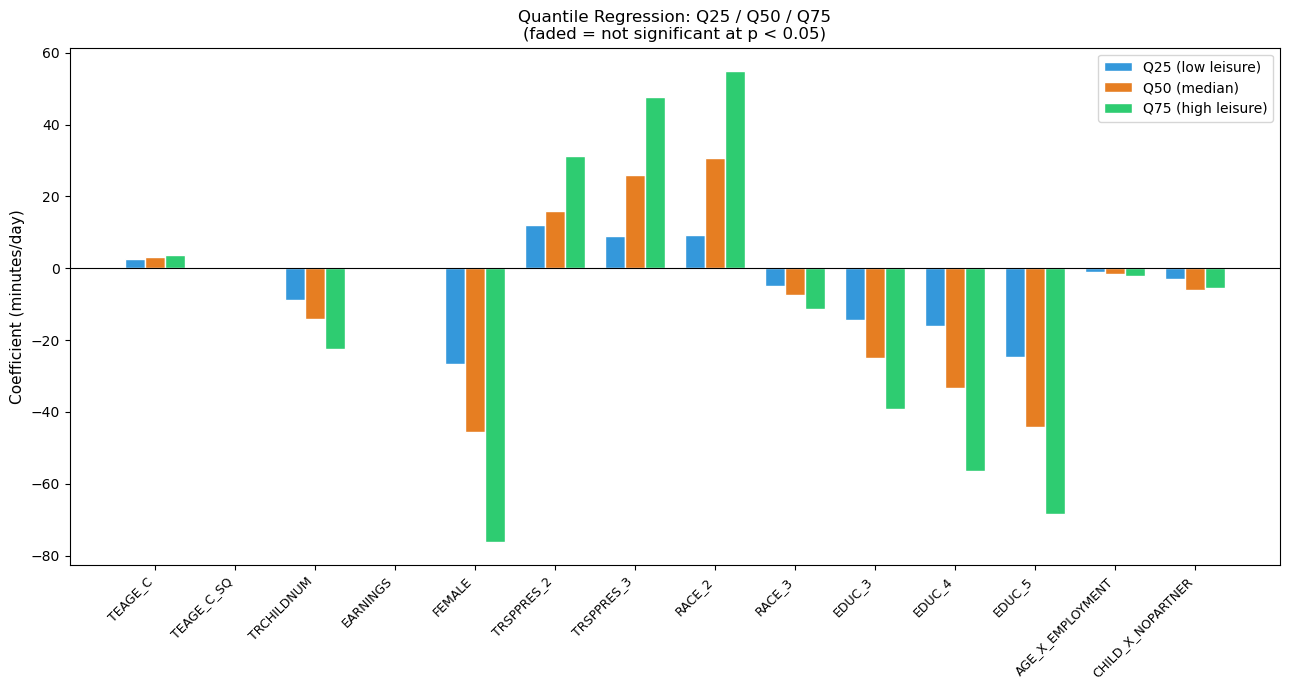

In [ ]:
plot_vars = [v for v in qr_cols if v in comp.index]
x         = np.arange(len(plot_vars))
width     = 0.25
colors_q  = ['#3498db','#e67e22','#2ecc71']
qlabels   = ['Q25 (low leisure)','Q50 (median)','Q75 (high leisure)']

fig, ax = plt.subplots(figsize=(13, 7))
for i, (q, color, lbl) in enumerate(zip(quantiles, colors_q, qlabels)):
    coeffs     = qr_results[q]['coef'][plot_vars]
    sig        = qr_results[q]['pval'][plot_vars] < 0.05
    bar_colors = [color if s else '#dddddd' for s in sig]
    ax.bar(x + i*width, coeffs, width, label=lbl,
           color=bar_colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(plot_vars, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Coefficient (minutes/day)', fontsize=11)
ax.set_title('Quantile Regression: Q25 / Q50 / Q75\n'
             '(faded = not significant at p < 0.05)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Step 9 — Model Comparison

All models evaluated on the same held-out test set.

In [ ]:
print('── Model comparison on held-out test set ──')
print(f'{"Model":<25} {"Test R²":>10} {"RMSE":>12}')
print('-' * 50)
print(f'{"Baseline OLS":<25} {base_r2:>10.4f} {"—":>12}')
print(f'{"Improved OLS":<25} {ols_r2:>10.4f} {ols_rmse:>10.2f} min')
print(f'{"Ridge (diagnostic)":<25} {ridge_r2:>10.4f} {"—":>12}')
print(f'{"Random Forest":<25} {rf_r2:>10.4f} {rf_rmse:>10.2f} min')
print()
best = max(ols_r2, rf_r2)


── Model comparison on held-out test set ──
Model                        Test R²         RMSE
--------------------------------------------------
Baseline OLS                  0.2345            —
Improved OLS                  0.2520     184.11 min
Ridge (diagnostic)            0.2520            —
Random Forest                 0.2657     182.41 min



---
## Step 10 — Prediction Function (Viz Team Handoff)

We use the improved OLS for predictions because it gives confidence intervals
natively via get_prediction(). Random Forest gives better R² but no natural CI.


In [ ]:
def predict_leisure(
    age, sex, employment_status, num_children,
    diary_day, holiday, partner_status,
    part_time=False, multi_job=False,
    weekly_earnings_dollars=0, year=2023,
    race='White', education='HS/GED'
):
    """
    Predict daily leisure time for a given demographic profile.

    Parameters
    ----------
    age                     : int  — age 15-85
    sex                     : str  — 'Male' or 'Female'
    employment_status       : str  — 'Employed (at work)', 'Employed (absent)',
                                     'Unemployed (layoff)', 'Unemployed (looking)',
                                     'Not in labor force'
    num_children            : int  — number of household children under 18
    diary_day               : str  — 'Sunday' through 'Saturday'
    holiday                 : str  — 'Yes' or 'No'
    partner_status          : str  — 'Spouse', 'Unmarried partner', 'No partner'
    part_time               : bool — working part-time? (default False)
    multi_job               : bool — more than one job? (default False)
    weekly_earnings_dollars : int  — weekly earnings in dollars (default 0)
    year                    : int  — 2010-2024 excl. 2020 (default 2023)
    race                    : str  — 'White', 'Black', 'Asian', 'Other' (default 'White')
    education               : str  — 'Less than HS', 'HS/GED', 'Some college',
                                     'Bachelors', 'Graduate' (default 'HS/GED')
    """
    emp_map     = {'Employed (at work)':1,'Employed (absent)':2,
                   'Unemployed (layoff)':3,'Unemployed (looking)':4,'Not in labor force':5}
    day_map     = {'Sunday':1,'Monday':2,'Tuesday':3,'Wednesday':4,
                   'Thursday':5,'Friday':6,'Saturday':7}
    partner_map = {'Spouse':1,'Unmarried partner':2,'No partner':3}
    race_map    = {'White':1,'Black':2,'Asian':3,'Other':4}
    educ_map    = {'Less than HS':1,'HS/GED':2,'Some college':3,'Bachelors':4,'Graduate':5}
    valid_years = [y for y in range(2010,2025) if y != 2020]

    female    = 1 if sex == 'Female' else 0
    telfs     = emp_map[employment_status]
    day       = day_map[diary_day]
    trsppres  = partner_map[partner_status]
    race_n    = race_map.get(race, 1)
    educ_n    = educ_map.get(education, 2)
    yr        = year if year in valid_years else 2023
    age_c     = age - age_mean
    absent    = 1 if telfs == 2 else 0
    nopartner = 1 if trsppres == 3 else 0


    earnings_missing = 1 if telfs in [3, 4, 5] else 0

    row = {
        'TEAGE_C':            age_c,
        'TEAGE_C_SQ':         age_c**2,
        'TRHOLIDAY':          1 if holiday=='Yes' else 0,
        'EARNINGS':           weekly_earnings_dollars,
        'EARNINGS_MISSING':   earnings_missing,
        'TRCHILDNUM':         num_children,
        'FEMALE':             female,
        'PART_TIME':          int(part_time),
        'MULTI_JOB':          int(multi_job),
        'FEMALE_X_CHILDNUM':  female * num_children,
        'AGE_X_EMPLOYMENT':   age_c * absent,
        'CHILD_X_NOPARTNER':  num_children * nopartner,
        'TELFS_2': 1 if telfs==2 else 0, 'TELFS_3': 1 if telfs==3 else 0,
        'TELFS_4': 1 if telfs==4 else 0, 'TELFS_5': 1 if telfs==5 else 0,
        'TUDIARYDAY_2': 1 if day==2 else 0, 'TUDIARYDAY_3': 1 if day==3 else 0,
        'TUDIARYDAY_4': 1 if day==4 else 0, 'TUDIARYDAY_5': 1 if day==5 else 0,
        'TUDIARYDAY_6': 1 if day==6 else 0, 'TUDIARYDAY_7': 1 if day==7 else 0,
        'TRSPPRES_2': 1 if trsppres==2 else 0, 'TRSPPRES_3': 1 if trsppres==3 else 0,
        'RACE_2': 1 if race_n==2 else 0, 'RACE_3': 1 if race_n==3 else 0,
        'RACE_4': 1 if race_n==4 else 0,
        'EDUC_2': 1 if educ_n==2 else 0, 'EDUC_3': 1 if educ_n==3 else 0,
        'EDUC_4': 1 if educ_n==4 else 0, 'EDUC_5': 1 if educ_n==5 else 0,
        **{f'YEAR_{y}': (1 if yr==y else 0) for y in valid_years if y != 2010}
    }

    input_df = pd.DataFrame([row])
    input_sm = sm.add_constant(input_df, has_constant='add')
    input_sm = input_sm.reindex(columns=X_train_sm.columns, fill_value=0)

    pred_summary = model_ols.get_prediction(input_sm).summary_frame(alpha=0.05)
    point   = float(pred_summary['mean'])
    ci_low  = float(pred_summary['mean_ci_lower'])
    ci_high = float(pred_summary['mean_ci_upper'])
    se      = float(pred_summary['mean_se'])
    hours, mins = int(point//60), int(point%60)

    print(f'Predicted: {point:.0f} min ({hours}h {mins}m)  |  95% CI: [{ci_low:.0f}, {ci_high:.0f}]')
    print(f'Profile: {age}yo {sex}, {employment_status}, {num_children} child(ren), {diary_day}, {yr}')
    print(f'         Race: {race}, Education: {education}')

    return {'predicted_minutes': round(point,1), 'predicted_hours_str': f'{hours}h {mins}m',
            'ci_low': round(ci_low,1), 'ci_high': round(ci_high,1), 'se': round(se,2)}

---
## Step 11 — Sanity Checks

| Check | Profile | Expected |
|---|---|---|
| 1 | Employed female, 2 kids, Thursday | Low — below 100 min |
| 2 | Retired male, no kids, Sunday | High — above 400 min |
| 3 | Gender gap (male minus female) | Larger than baseline ~60 min |
| 4 | Education effect | Graduate < Less than HS |
| 5 | Race check | Black minus White ≈ +34 min |

In [ ]:
print('── Check 1: employed female, 2 kids, Thursday ──')
r1 = predict_leisure(35,'Female','Employed (at work)',2,'Thursday','No','Spouse',year=2023)
print()
print('── Check 2: retired male, no kids, Sunday ──')
r2 = predict_leisure(70,'Male','Not in labor force',0,'Sunday','No','Spouse',year=2023)
print()
print('── Check 3: same as #1 but male ──')
r3 = predict_leisure(35,'Male','Employed (at work)',2,'Thursday','No','Spouse',year=2023)
print(f'Gender gap: {r3["predicted_minutes"]-r1["predicted_minutes"]:.1f} min')
print()
print('── Check 4: education effect ──')
r4a = predict_leisure(40,'Male','Employed (at work)',0,'Monday','No','No partner',education='Graduate')
r4b = predict_leisure(40,'Male','Employed (at work)',0,'Monday','No','No partner',education='Less than HS')
print(f'Education gap (Graduate minus < HS): {r4a["predicted_minutes"]-r4b["predicted_minutes"]:.1f} min (negative = grad has less)')
print()
print('── Check 5: race effect ──')
r5a = predict_leisure(40,'Male','Employed (at work)',0,'Monday','No','No partner',race='White')
r5b = predict_leisure(40,'Male','Employed (at work)',0,'Monday','No','No partner',race='Black')
print(f'Race gap (Black minus White): {r5b["predicted_minutes"]-r5a["predicted_minutes"]:.1f} min')

── Check 1: employed female, 2 kids, Thursday ──
Predicted: 103 min (1h 43m)  |  95% CI: [97, 110]
Profile: 35yo Female, Employed (at work), 2 child(ren), Thursday, 2023
         Race: White, Education: HS/GED

── Check 2: retired male, no kids, Sunday ──
Predicted: 456 min (7h 36m)  |  95% CI: [450, 462]
Profile: 70yo Male, Not in labor force, 0 child(ren), Sunday, 2023
         Race: White, Education: HS/GED

── Check 3: same as #1 but male ──
Predicted: 169 min (2h 49m)  |  95% CI: [163, 176]
Profile: 35yo Male, Employed (at work), 2 child(ren), Thursday, 2023
         Race: White, Education: HS/GED
Gender gap: 66.0 min

── Check 4: education effect ──
Predicted: 210 min (3h 29m)  |  95% CI: [203, 217]
Profile: 40yo Male, Employed (at work), 0 child(ren), Monday, 2023
         Race: White, Education: Graduate
Predicted: 256 min (4h 15m)  |  95% CI: [248, 263]
Profile: 40yo Male, Employed (at work), 0 child(ren), Monday, 2023
         Race: White, Education: Less than HS
Education ga

---
## Key Findings Summary

| Finding | Evidence | Model |
|---|---|---|
| Gender gap: women get ~62 min less leisure | `FEMALE` = -61.6, p=0.000 | OLS |
| Employment status is the strongest predictor | `TELFS_5` = +143 min vs employed at work | OLS |
| Each child costs ~17 min of leisure | `TRCHILDNUM` = -17.4 per child | OLS |
| Working two jobs costs ~34 min | `MULTI_JOB` = -34.3, stronger than child penalty | OLS |
| Education gradient: more = less leisure | Graduate = -46 min vs HS/GED baseline | OLS |
| Race differences persist after all controls | Black = +33 min, Asian = -18 min | OLS |
| Structural shift post-2021 | `YEAR_2021` = +24 min, largest year effect | OLS |
| Gender gap triples from Q25 to Q75 | -26 → -46 → -76 min/day | Quantile regression |
| Child penalty grows with leisure level | -9 → -14 → -22 min per child Q25 to Q75 | Quantile regression |
| Penalties concentrate among high-leisure groups | All major effects grow Q25 → Q75 | Quantile regression |
| R² below 0.30 target | Best: ~0.27 (RF) | All models |
| OLS is not overfit | Ridge finds near-identical R² | Ridge |
| Nearly all features carry signal | Lasso zeroes very few variables | Lasso |